## Diffusion
- Add gaussian noise for time steps. Mean is 0, variance determined by the noise scheduler 
- Instead of adding each time step, we can add cummulative noise for lets say 25 steps at once with use of alpha and alpha hat parameter

### Forward going from X0 to Xt:

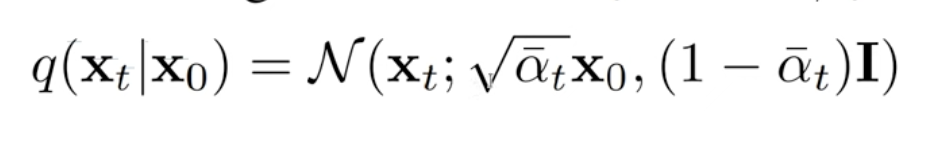


## Traing and sampling
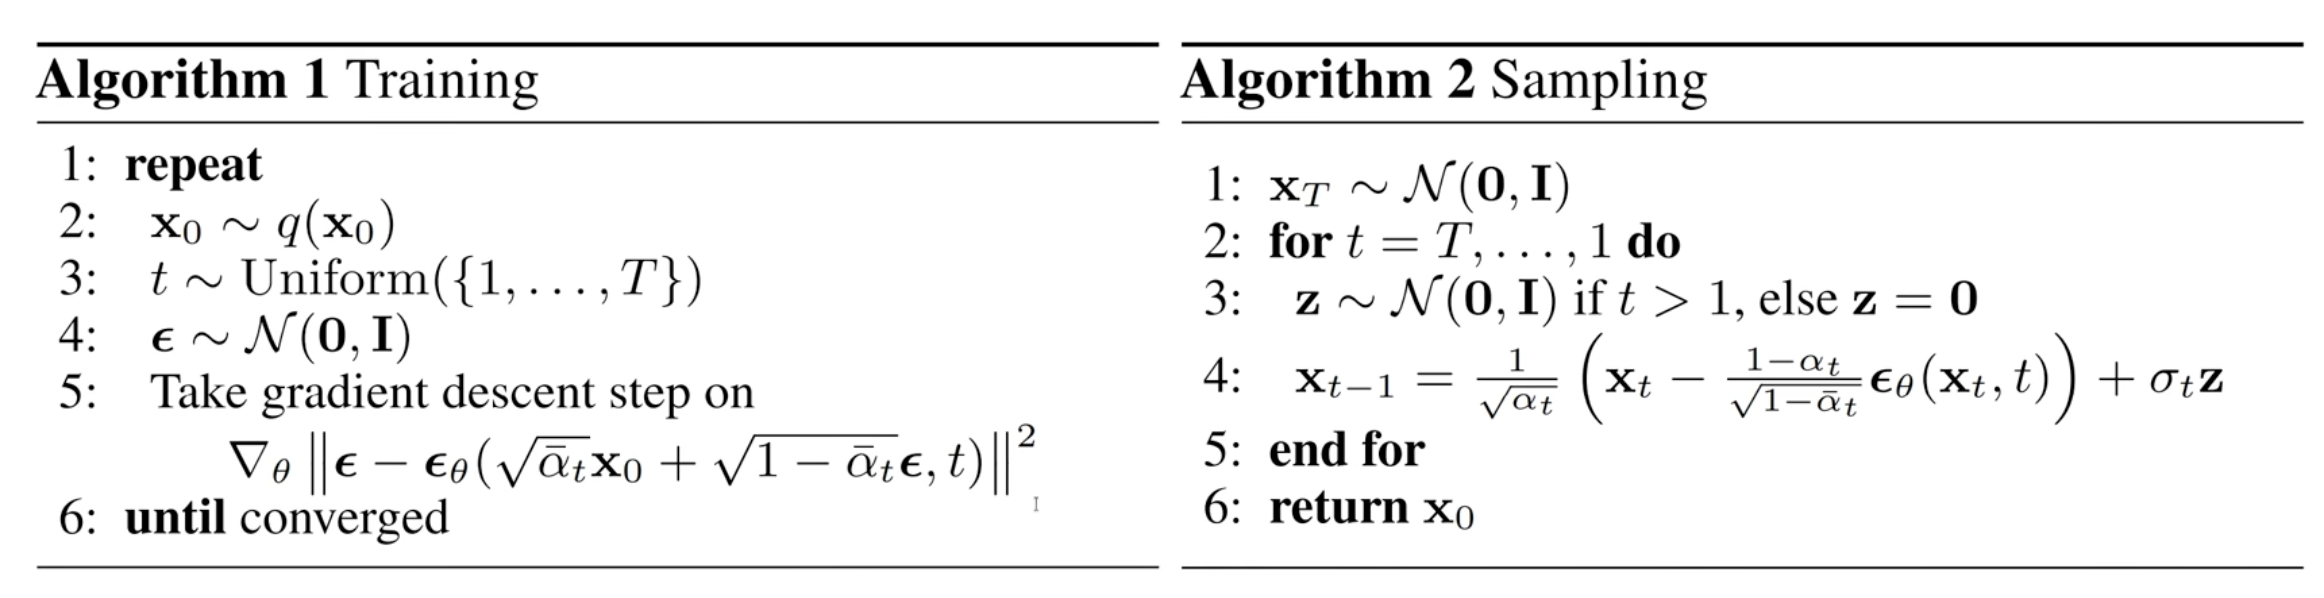


## 
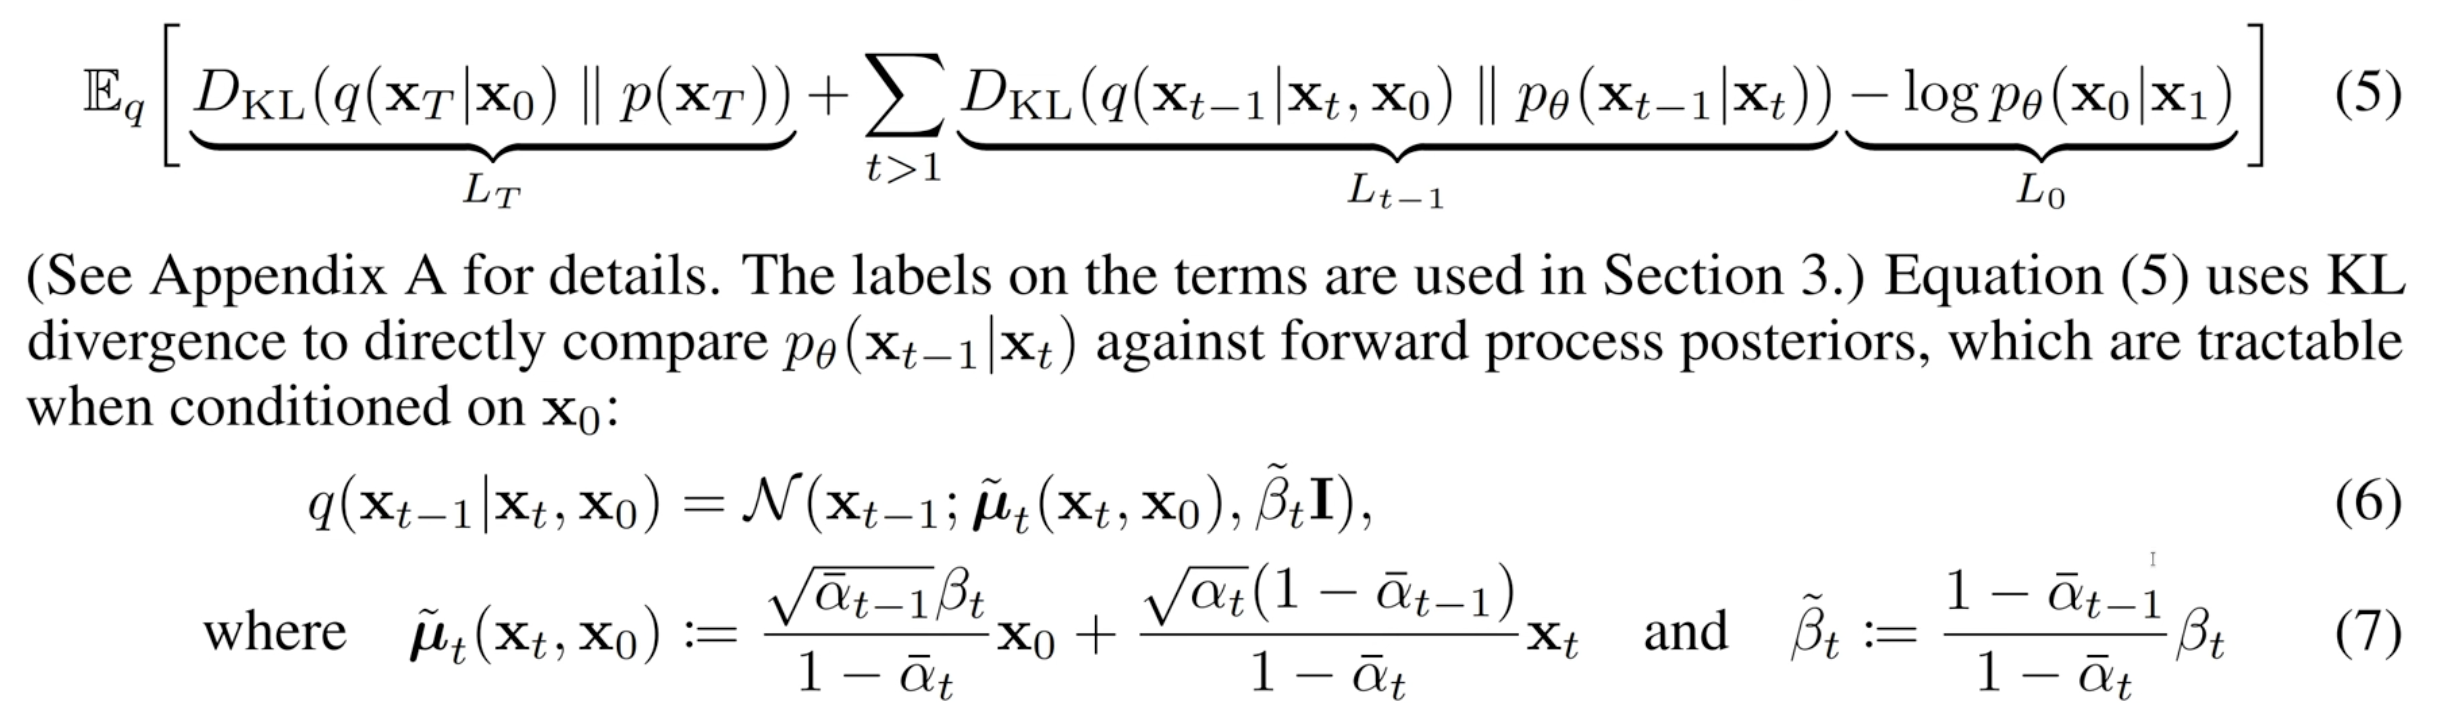

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np

from torchvision.datasets import ImageFolder
from torchvision import transforms 
from PIL import Image
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from dataclasses import dataclass

### Sampler

In [3]:
class Sampler:
    """
    beta -> noise we are going to add at time step t.
    alpha -> 1 - beta 
    alpha_hat -> alpha_cumprod
    sigma_t -> std. dev from variance (which is beta_t_tilda) 
    """
    def __init__(self, num_steps = 1000, beta_start = 0.0001 , beta_end = 0.01):
        self.num_steps = num_steps
        self.beta_start = beta_start
        self.beta_end = beta_end

        self.beta_schedule = self.linear_beta_scheduler()

        self.alpha = 1 - self.beta_schedule
        self.alpha_cumprod = torch.cumprod(self.alpha, dim = -1)

    def linear_beta_scheduler(self):
        return torch.linspace(self.beta_start, self.beta_end, self.num_steps)
    
    def _repeat_unsqueeze(self, input, target):
        while input.dim() < target.dim():
            input = input.unsqueeze(-1)
        return input

    def add_noise(self, data, ts):
        device = data.device

        noise = torch.randn_like(data)
        alpha_hat = self.alpha_cumprod[ts].to(device)

        mean_coeff = alpha_hat ** 0.5
        var_coeff = (1 - alpha_hat) ** 0.5
        mean_coeff = self._repeat_unsqueeze(mean_coeff, data)
        var_coeff = self._repeat_unsqueeze(var_coeff, data)
        
        # add noise to data 
        noisy_data = mean_coeff * data + var_coeff * noise

        return data, noisy_data

    def remove_noise(self, data, ts, predicted_noise):
        device = data.device

        noise = torch.randn_like(data)

        beta_t = self.beta_schedule[ts].to(device)
        alpha_t = self.alpha[ts].to(device)
        alpha_hat_t = self.alpha_cumprod[ts].to(device)
        alpha_hat_t_prev = self.alpha_cumprod[ts-1].to(device)
        
        ## for ts 0 there is no prev alpha -> here we set to 1.0
        ts_zero_mask = ( ts ==0 )
        alpha_hat_t_prev[ts_zero_mask] = 1.0

        ## sigma_t
        variance = ( (1 - alpha_hat_t_prev) * beta_t)/ (1 - alpha_hat_t)
        variance = self._repeat_unsqueeze(variance, data) 
        sigma_t_z = variance ** 0.5 * noise

        ## noise coeff
        noise_coeff = beta_t / ( 1 - alpha_hat_t ) ** 0.3
        noise_coeff = self._repeat_unsqueeze(noise_coeff, data)

        reciproc_root_alpha_t = alpha_t ** -0.5
        reciproc_root_alpha_t = self._repeat_unsqueeze(reciproc_root_alpha_t, data)

        # denoise image by mean
        mean = reciproc_root_alpha_t * ( data - noise_coeff * noise )
        denoised_data = mean + sigma_t_z

        return denoised_data



sampler = Sampler()
img = torch.randn( 4, 3, 32, 32 )

## get rand time step of noise to add to (batch_size,) of images
rand_ts = torch.randint( low = 0, high = 1000, size = (4,) )
pred_noise = torch.randn( 4, 3, 32, 32 )
#sampler.add_noise(img, rand_ts)
sampler.remove_noise(img, rand_ts, pred_noise).shape


torch.Size([4, 3, 32, 32])

In [39]:
torch.rand((1,3,3)).squeeze(0).shape

torch.Size([3, 3])

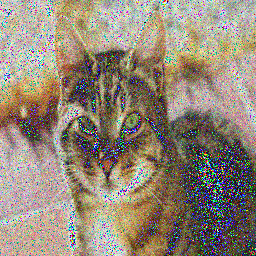

In [25]:
cat = Image.open('./cat.jpg').convert("RGB")

image2tensor_transform = transforms.Compose([
                    transforms.Resize((256, 256)), # Resize Image
                    transforms.ToTensor(), # Convert to tensor (will scale from 0 to 1)
                    transforms.Lambda(lambda t: (t*2) - 1), # Change scale to be -1 to 1
                    transforms.Lambda(lambda t: t.unsqueeze(0))
])

tensor2image_transform = transforms.Compose([
        transforms.Lambda(lambda t: t.squeeze(0)), # Remove batch dimension on
        transforms.Lambda(lambda t: (t + 1) / 2), # Scale back to 0 to 1
        transforms.Lambda(lambda t: t.permute(1, 2, 0)), # Make channels last 
        transforms.Lambda(lambda t: t * 255.), # Scale back to 0 to 255
        transforms.Lambda(lambda t: t.cpu().numpy().astype(np.uint8)), # Convert to numpy
        transforms.ToPILImage(), # Conver to PIL
    ])

tensor2image_transform( sampler.add_noise( image2tensor_transform(cat), 100 )[1] )

## Self Attention

In [75]:
@dataclass
class TransformerConfig:
    n_head = 8
    n_layers = 8
    ff_drop = proj_p = attn_p = 0.0
    mlp_ratio = 4
    channels = 32

t_config = TransformerConfig()

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.qkv = nn.Linear(self.config.channels, self.config.channels * 3)
        self.head_dim = config.channels // config.n_head
        self.attn_p = config.attn_p
        self.proj = nn.Linear(self.config.channels, self.config.channels)
        self.proj_p = nn.Dropout(self.config.proj_p)

    def forward(self, x ):
        B, T, C = x.shape

        qkv = self.qkv(x).reshape(B, T, 3, self.config.n_head, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4) # 3(q, k, v) x B x H x T x D
        q, k, v = qkv.unbind(0)

        x = F.scaled_dot_product_attention(q, k, v, dropout_p=self.config.attn_p)
        x = x.transpose(1,2).reshape(B, T, C)
        x = self.proj_p ( self.proj(x) )
        return x
    
class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        hddn_dim = self.config.channels * self.config.mlp_ratio
        self.proj_in = nn.Linear(self.config.channels, hddn_dim)
        self.act = nn.GELU()
        self.proj_out = nn.Linear(hddn_dim, self.config.channels)
        self.ff_drop = nn.Dropout(self.config.ff_drop)

    def forward(self, x):
        x = self.proj_in(x)
        return self.ff_drop( self.proj_out( self.act(x) ) )

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.mlp = MLP(self.config)
        self.sa = SelfAttention(self.config)
        self.ln1 = nn.LayerNorm(self.config.channels)
        self.ln2 = nn.LayerNorm(self.config.channels)

    def forward(self, x):
        B, C, H, W = x.shape
        
        x = x.reshape(B, C, H * W).permute(0, 2, 1)
        x = x + self.sa(self.ln1(x))
        x = x + self.mlp( self.ln2(x) )

        x = x.permute(0, 2, 1).reshape(B, C, H, W)
        return x

t = TransformerBlock(config=t_config)
img = torch.randn((1, 32, 128, 128))
t(img).shape

torch.Size([1, 32, 128, 128])